# Tutorial on `gwg` 

Estimating the residual foreground Gravitational Wave signal generated by the compact binaries in the vicinity of our Galaxy. 

LISA will measure a very large number of transient and quasi-monochromatic sources. For this reason, a [Global Fit](https://www.youtube.com/watch?v=8Xe4JNCzlRg) analysis strategy has been proposed, consisting essentially of a large-scale Blocked-Gibbs sampling scheme. This scheme is, however, computationally expensive, which may prohibit us from performing forecast studies of stellar population models with LISA. The `gwg` software, on the other hand, offers a cost-effective alternative, as it is based on SNR criteria and simplifying assumptions. It can therefore serve as a simulation of the Global Fit pipeline, yielding robust results and enabling the aforementioned studies.

[Nikolaos Karnesis](https://karnesis.github.io/aboutme/) 2026 

[1] [ACME Hands-on sessions](https://www.acme-astro.eu/hands-on-sessions/)

[2] [Session indico page](https://indico.global/event/17933/)

[3] [`gwg` gitlab page](https://gitlab.in2p3.fr/Nikos/gwg)

[4] Relevant publication: [Phys. Rev. D 104.043019](https://doi.org/10.1103/PhysRevD.104.043019).

Installation instructions are given below. Those might change a bit depending on your machine. We need the [`LISAanalysistools`](https://github.com/mikekatz04/LISAanalysistools) and the [`GBGPU`](https://github.com/mikekatz04/gbgpu) codes. Please refer to their corresponding documentation for details.

```shell
$ conda create -n gwg_env -c conda-forge gsl numpy scipy jupyter pandas matplotlib xarray h5py tqdm pytables astropy python=3.12

$ conda activate gwg_env

$ git clone https://github.com/mikekatz04/LISAanalysistools.git
$ cd LISAanalysistools
$ pip install .

$ pip install gbgpu

$ git clone https://gitlab.in2p3.fr/Nikos/gwg.git
$ cd gwg/
$ pip install .

```
We may also want to install the [fastgb](https://pypi.org/project/fastgb/) package, which is an implementation of the original CPU version of the waveform, and the `whittaker-eilers` filters package that gives us more options for smoothening the data.
```shell
$ pip install whittaker-eilers
$ pip install fastgb
```


First we need to import basic packages. It is possible to run the code on GPUs, and for the moment we need to have this try-catch snippet in order to avoid errors. This is a known issue and will be fixed in future releases of the waveform software.

In [1]:
import numpy as np
import pandas as pd
import gwg
from gbgpu.gbgpu import GBGPU

# make the plots look a bit nicer with some defaults
import matplotlib as mpl
import matplotlib.pyplot as plt
rcparams = {}
rcparams["axes.linewidth"] = 0.5
rcparams["font.family"] = "serif"
rcparams["font.size"] = 16
rcparams["legend.fontsize"] = 14
rcparams["mathtext.fontset"] = "stix"
rcparams["text.usetex"] = True
rcparams["font.family"] = "serif"
mpl.rcParams.update(rcparams) # update plot parameters

try:
    import cupy.cuda.runtime as rt
    if not hasattr(rt, "_getLocalRuntimeVersion"):
        rt._getLocalRuntimeVersion = rt.runtimeGetVersion
    import cupy as cp
    gbgpu_available = True
except ModuleNotFoundError:
    cp = None
    gbgpu_available = False

print(f"gbgpu_available = {gbgpu_available}")

gbgpu_available = False


We then need to define a duration for the measurement. LISA is epxected to run for 4.5 years, but in order to make things more lightweight we set it to one year. Given this duration and a cadence time `dt`, we can derive the frequency bins for our data.

In [2]:
YEAR = 3.154e7
duration = 1.0 * YEAR
dt = 15.0
df = 1.0 / duration

ndata = int(duration / dt)
nfft = int(ndata / 2 + 1) if ndata % 2 == 0 else int((ndata + 1) / 2)
fvec = np.arange(1, nfft) * df # Skip the zero

We will use our own homemade LISA noise curve, which is based on the [`SCiRD`](https://atrium.in2p3.fr/nuxeo/nxpath/default/Atrium/sections/Public/LISA/LISA-SciRD-ESA-L3-EST-SC@view_documents?tabIds=%3A) document. In general we may use any data or function for the noise. The code will interpolate it to the frequencies of the data internaly.  

In [3]:
noise = gwg.utils.lisa_noise(f=fvec)

lisa_noise = {
    "A": noise._noise_psd_AA().astype(np.float64),
    "E": noise._noise_psd_AA().astype(np.float64), # Same as A channel
    "T": noise._noise_psd_TT().astype(np.float64),
    "f": fvec.astype(np.float64),
}

print(f"Noise grid bins: {len(lisa_noise["f"])}")
print(f"avg_d = {noise.avg_d:.4f} s, df = {df:.2e} Hz, fmax = {fvec[-1]:.2e} Hz")

Noise grid bins: 1051333
avg_d = 8.3391 s, df = 3.17e-08 Hz, fmax = 3.33e-02 Hz


Generate some catalogue of sources. This silly simple function just draws some random parameters for a given number of sources `n_sources`. The various positional arguments control a bit the distributions for the parameters. This function is not realistic at all, if you want to learn more about how to properly do scuh simulations you can check the work of the Astrophysics Working Group of the LISA Consortium (see for example the [LISA Astrophysics White Paper](https://arxiv.org/abs/2203.06016)).

In [4]:
cat = gwg.utils.make_demo_catalog(n_sources=5000000, n=-1.5, gamma=1, offset=-26.5, fmin=3e-5)

print(f"Catalog size: {len(cat)}")

Catalog size: 5000000


We then declare the waveform model to be used. It should be fairly easy to go into the code and replace the waveform model with your favourite one. In more primitive versions of the code we worked with stellar-mass Black Hole binaries, and Extreme Mass Ratio Inspirals. Here we prefer to use `GBGPU` because it supports GPU hardware. 

In [5]:
from lisatools.detector import EqualArmlengthOrbits

# Define the orbits
orbits = EqualArmlengthOrbits(use_gpu=gbgpu_available)

# Define the waveform class
GB = GBGPU(force_backend="cpu", orbits=orbits)

We are now ready to generate the data for the given catalogue. Depending on its length, this might take a while. GPUs help a lot in this regard! In more detail:

- We generate waveforms for TDI variables AET.
    - Assume equal-arms constellation, uninterrupted measurement for the given observational time.
    - This means we get uncorrelated data channels!
    - Compute the optimal SNR ρ0, which is w.r.t. instrumental noise only. It will be used for making the process faster.


In [6]:
tdi, cat_out = gwg.generate_data(
    cat=cat,
    noise=lisa_noise,
    GB=GB,
    T=duration,
    dt=dt,
    AET=True,
    oversample=1,
    batch_size=128,
    gbgpu_available=gbgpu_available,
    tdi2=True,
)

print("Generated channels:", list(tdi.keys()))
print("Output catalog fields:", cat_out.dtype.names)

Progress: 100%|██████████████████████████| 39062/39062 [05:26<00:00, 119.75it/s]


Generated channels: ['A', 'E', 'T']
Output catalog fields: ('Amplitude', 'Frequency', 'FrequencyDerivative', 'FrequencySecondDerivative', 'InitialPhase', 'Inclination', 'Polarization', 'EclipticLongitude', 'EclipticLatitude', 'snr2')


In [7]:
print("Max SNR^2:", np.max(cat_out["snr2"]))
print("Mnx SNR^2:", np.min(cat_out["snr2"]))

Max SNR^2: 1.4804874688166922e+19
Mnx SNR^2: 9.904919850410366e-17


Text(0, 0.5, '\\# of sources')

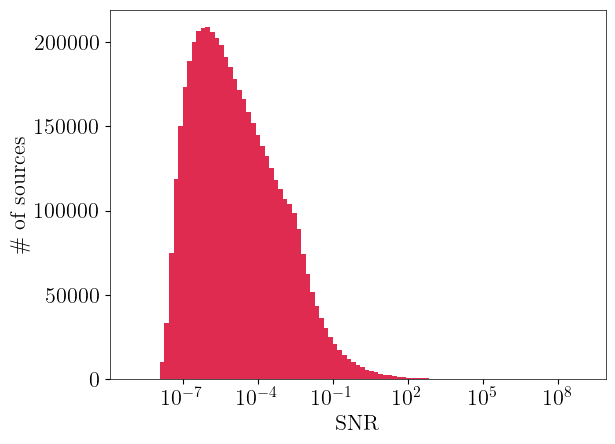

In [8]:
plt.hist(np.sqrt(cat_out["snr2"]), bins=np.logspace(-9,9,num=100), alpha=.9, color="crimson")
plt.xscale("log")
plt.xlabel("SNR")
plt.ylabel("\\# of sources")

In the next cell we use our built-in functions to store and load catalogues and data.

In [9]:
out_file = "minimal_gwg_output.h5"
gwg.utils.to_h5(out_file, cat=cat_out, tdi=tdi, S=None)

loaded_cat = gwg.utils.load_h5(out_file, key="cat")
loaded_tdi = gwg.utils.load_h5(out_file, key="tdi")

print(f"Saved and reloaded: {out_file}")
print(f"Loaded catalog length: {len(loaded_cat)}")
print(f"Loaded TDI keys: {list(loaded_tdi.keys())}")

Saved and reloaded: minimal_gwg_output.h5
Loaded catalog length: 5000000
Loaded TDI keys: ['A', 'E', 'T', 'f']


Let us plot the data now:

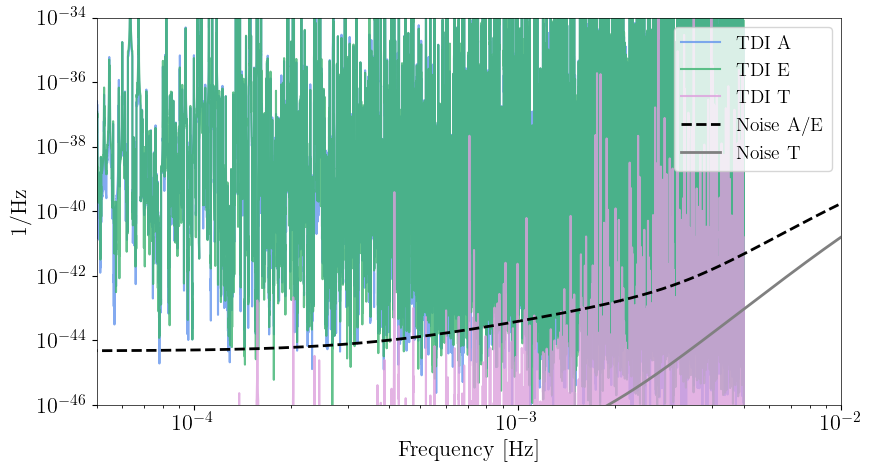

In [10]:
A = gwg.utils.FrequencySeries(loaded_tdi["A"], df=df, kmin=0)
E = gwg.utils.FrequencySeries(loaded_tdi["E"], df=df, kmin=0)
T = gwg.utils.FrequencySeries(loaded_tdi["T"], df=df, kmin=0)
f = np.array(A.f)

alpha = .8 # just being fancy

plt.figure(figsize=(9, 5))
plt.loglog(f[1:], 2 * df * np.abs(A[1:]) ** 2, label="TDI A", alpha=alpha, color="cornflowerblue")
plt.loglog(f[1:], 2 * df * np.abs(E[1:]) ** 2, label="TDI E", alpha=alpha, color="mediumseagreen")
plt.loglog(f[1:], 2 * df * np.abs(T[1:]) ** 2, label="TDI T", alpha=alpha, color="plum")
plt.loglog(lisa_noise["f"], lisa_noise["A"], "k--", lw=2, label="Noise A/E")
plt.loglog(lisa_noise["f"], lisa_noise["T"], "gray", lw=2, label="Noise T")
plt.xlim(5e-5, 1e-2)
plt.ylim(1e-46, 1e-34)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$1/\mathrm{Hz}$")
plt.legend(loc="upper right", )
plt.tight_layout()
plt.show()

This is an important step. We need to choose the SNR threshold to help us classify sources as resolvables. There have been quite a few references in literature where for Galactic Binaries they place this number between 7 and 20. 

In [11]:
snr_thresh = 7

Here is the heart of the iterative subtraction algorithm. Here is hwat happens in detail:

- We begin the process of the iterative subtraction ($n=0$). We choose an SNR threshold ρthres where sources can be assumed resolvable ($\rho\sim10$).
    1. From the accompanied catalogue (remember, we now have $\rho_0$), we choose a subset of potentially resolvable sources, for which $\rho_0 > \kappa \rho_\mathrm{thres}$ and $0<\kappa<1$ a safety margin constant.
    2. We do a first estimate of the overall confusion $S_{n=0}$ by smoothening the data.
    3. We iterate the reduced catalogue and check if $\rho_i > \rho_\mathrm{thres}$, for each source $i$.  If true we subtract source $i$ from the data and from the reduced catalogue, and mark $i$ as resolvable.
    4. After finishing running over the catalogue, we estimate the overall confusion $S_{n=1}$ anew from the residuals.
    5. Go to (3). Repeat until convergence: $S_n-1 \sim  S_n$ .

In [12]:
AET, S1, S1r, final_cat = gwg.icloop(loaded_tdi, GB, loaded_cat, lisa_noise, 3000, maxiter=10,
                               snr_thresh2=snr_thresh**2, tol=0.1,
                               doplot=True, oversample=1, 
                               methoduse='median', extra_smooth=True,
                               extra_smooth_type="whittaker", order=1e7)

2026-05-08 18:27:11,502 - lisa - INFO - Interpolating noise on the freq. vector of the data.


2026-05-08 18:27:11,518 - lisa - INFO - Starting analysis with dt=15 [sec] and T=31540000.0 [sec].
2026-05-08 18:27:11,538 - lisa - INFO - Selecting (19984/5000000) sources for subtraction
2026-05-08 18:27:11,542 - lisa - INFO - First smoothing
2026-05-08 18:27:12,420 - lisa - INFO - First smoothing done
2026-05-08 18:27:12,941 - lisa - INFO - Iteration #0
Iteration #0
2026-05-08 18:27:13,968 - lisa - INFO - Gathering subtracted sources
2026-05-08 18:27:13,971 - lisa - INFO - 3991 sources subtracted at iter 0. Smoothing for iter 1
2026-05-08 18:27:14,883 - lisa - INFO - Smoothing done
2026-05-08 18:27:15,440 - lisa - INFO - Total subtracted: 3991/19984
2026-05-08 18:27:15,441 - lisa - INFO - Reduced cat to 15993 non-subtracted sources
2026-05-08 18:27:15,442 - lisa - INFO - Iteration #1
Iteration #1
2026-05-08 18:27:16,350 - lisa - INFO - Gathering subtracted sources
2026-05-08 18:27:16,353 - lisa - INFO - 6575 sources subtracted at iter 1. Smoothing for iter 2
2026-05-08 18:27:17,283 

Final SNR: 100%|██████████████████████████████████| 3/3 [00:00<00:00,  3.48it/s]


In [13]:
final_cat

array([(4.13359594e-21, 0.00439593, 0., 0., 5.75743841, 1.76026176, 0.29511711,  2.96703398, -0.63958207, 4.01279600e+06),
       (8.28949694e-19, 0.00052682, 0., 0., 0.05110433, 2.44036332, 3.10582032, -1.04019338, -0.97265752, 3.44203533e+08),
       (4.90262788e-18, 0.00020697, 0., 0., 2.73158066, 2.38582149, 1.21624763,  2.36065595,  1.02555703, 9.19505265e+07),
       ...,
       (3.91206472e-21, 0.00025259, 0., 0., 0.9313852 , 2.12991135, 1.15778785, -2.40411569, -0.17086937, 1.29771529e+02),
       (1.04129389e-22, 0.00129965, 0., 0., 3.17866553, 1.4941189 , 1.54058917, -0.3527347 , -0.13646292, 6.38243901e+01),
       (6.61434958e-23, 0.00160288, 0., 0., 0.48498931, 1.63253051, 0.45735171, -1.12881668,  0.55018747, 6.09776802e+01)],
      shape=(18167,), dtype=[('Amplitude', '<f8'), ('Frequency', '<f8'), ('FrequencyDerivative', '<f8'), ('FrequencySecondDerivative', '<f8'), ('InitialPhase', '<f8'), ('Inclination', '<f8'), ('Polarization', '<f8'), ('EclipticLongitude', '<f8'), ('

In [14]:
final_cat.shape

(18167,)

In [15]:
S1.keys()

dict_keys(['A', 'E', 'T', 'f'])

In [16]:
AET.keys()

dict_keys(['A', 'E', 'T', 'f'])

In [17]:
AET

{'A': <xarray.DataArray (f: 1051334)> Size: 17MB
 array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       shape=(1051334,))
 Coordinates:
   * f        (f) float64 8MB 0.0 3.171e-08 6.341e-08 ... 0.03333 0.03333 0.03333
 Attributes:
     units:    None
     df:       3.170577045022194e-08
     kmin:     0
     t0:       0,
 'E': <xarray.DataArray (f: 1051334)> Size: 17MB
 array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       shape=(1051334,))
 Coordinates:
   * f        (f) float64 8MB 0.0 3.171e-08 6.341e-08 ... 0.03333 0.03333 0.03333
 Attributes:
     units:    None
     df:       3.170577045022194e-08
     kmin:     0
     t0:       0,
 'T': <xarray.DataArray (f: 1051334)> Size: 17MB
 array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       shape=(1051334,))
 Coordinates:
   * f        (f) float64 8MB 0.0 3.171e-08 6.341e-08 ... 0.03333 0.03333 0.03333
 Attributes:
     units:    None
     df:       3.170577045022194e-08
     kmin:     0
     t0

Plot the final result

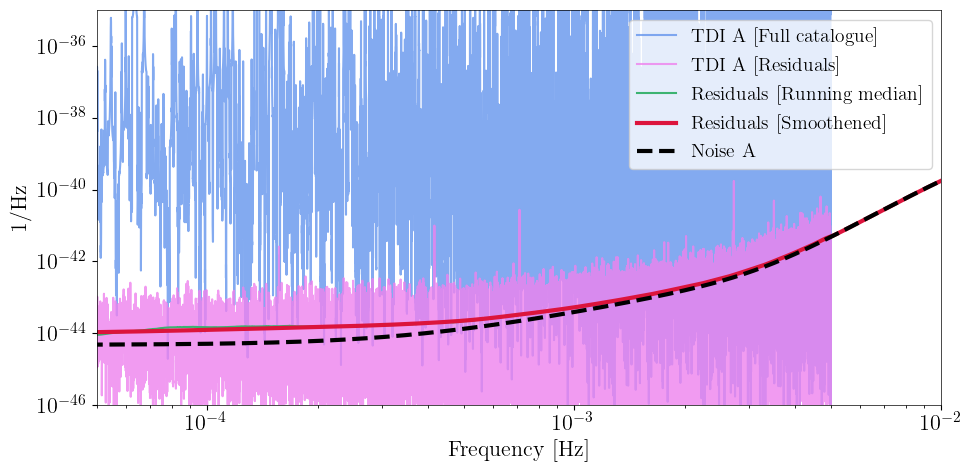

In [18]:
plt.figure(figsize=(10, 5))
plt.loglog(f[1:], 2 * df * np.abs(A[1:]) ** 2, label="TDI A [Full catalogue]", alpha=alpha, color="cornflowerblue")
plt.loglog(f[1:], 2 * df * np.abs(AET["A"][1:]) ** 2, label="TDI A [Residuals]", alpha=alpha, color="violet")
plt.loglog(f[1:],np.abs(S1r["A"][1:]), label="Residuals [Running median]", color="mediumseagreen")
plt.loglog(f[1:],np.abs(S1["A"][1:]), label="Residuals [Smoothened]", color="crimson", lw=3)
plt.loglog(lisa_noise["f"][1:], lisa_noise["A"][1:], "k--", lw=3, label="Noise A")
plt.xlim(5e-5, 1e-2)
plt.ylim(1e-46, 1e-35)
plt.xlabel("Frequency [Hz]")
plt.ylabel(r"$1/\mathrm{Hz}$")
plt.legend(loc="upper right",)
plt.tight_layout()
plt.show()

Text(0, 0.5, '\\# of sources')

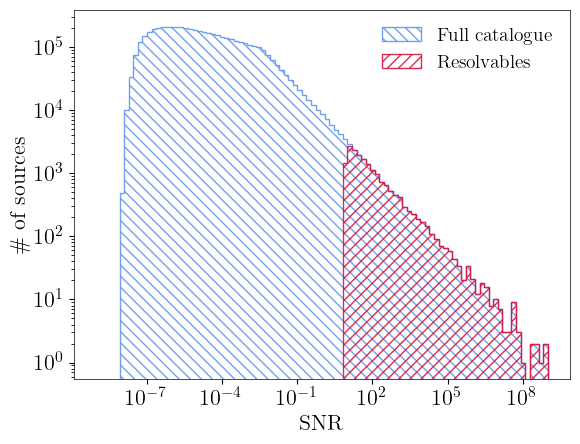

In [19]:
plt.hist(np.sqrt(cat_out["snr2"]), bins=np.logspace(-9,9,num=100), alpha=.9, 
                                   facecolor="none", histtype="stepfilled", label="Full catalogue", 
                                   hatch="\\\\\\", edgecolor="cornflowerblue", lw=1)
plt.hist(np.sqrt(final_cat["snr2"]), bins=np.logspace(-9,9,num=100), alpha=.9, 
                                     facecolor="none", histtype="stepfilled",
                                     label="Resolvables", 
                                     hatch="///", 
                                     edgecolor="crimson", lw=1)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("SNR")
plt.legend(loc="upper right", frameon=False)
plt.ylabel("\\# of sources")

# $fin$